## 데이터 불러오기

In [2]:
import pandas as pd

# 1. 데이터 로드 (파일 경로를 본인 환경에 맞게 수정하세요)
df = pd.read_csv('train.csv')

# 2. 데이터 크기(Shape) 확인 -> 과제 필수 조건!
print("데이터 Shape:", df.shape)

# 3. 데이터 상위 5개 행 보기
df.head()

데이터 Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 타겟 분리 및 기본 세팅

In [9]:
# 1. 정답(Target)과 입력 데이터(X) 분리
# 에러 원인이었던 'Cabin' 컬럼을 드롭 리스트에 추가합니다!
X_raw = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])

# 2. 파생 변수(Feature Generation) 만들기
X_raw['FamilySize'] = X_raw['SibSp'] + X_raw['Parch'] + 1
X_raw['IsAlone'] = (X_raw['FamilySize'] == 1).astype(int)

print("수정 후 컬럼들:\n", X_raw.columns.tolist())

수정 후 컬럼들:
 ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


## Base

In [10]:
# 수치형 변수만 그냥 가져옴 (결측치 처리 X, 스케일링 X)
X_base = X_raw.select_dtypes(include=['int64', 'float64']).copy()

## Exp-1 (Mean + One-Hot + Standard)

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd
import numpy as np

X_1 = X_raw.copy()

# 1. 결측치 처리: 수치형은 평균(Mean), 범주형은 최빈값
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
cat_cols = ['Sex', 'Embarked']

imputer_num = SimpleImputer(strategy='mean')
X_1[num_cols] = imputer_num.fit_transform(X_1[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_1[cat_cols] = imputer_cat.fit_transform(X_1[cat_cols])

# 2. 인코딩: One-Hot Encoding
X_1 = pd.get_dummies(X_1, columns=cat_cols, drop_first=True)

# 3. 스케일링: StandardScaler
scaler_1 = StandardScaler()
# 문자로 바뀐 컬럼들을 제외한 수치형 컬럼들만 스케일링
X_1[num_cols] = scaler_1.fit_transform(X_1[num_cols])

## Exp-2 (Median + Label + MinMax + Feature Selection)

In [12]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

X_2 = X_raw.copy()

# 1. 결측치 처리: 중앙값(Median)
imputer_num_2 = SimpleImputer(strategy='median')
X_2[num_cols] = imputer_num_2.fit_transform(X_2[num_cols])
X_2[cat_cols] = imputer_cat.fit_transform(X_2[cat_cols]) # 범주형은 최빈값

# 2. 인코딩: Label Encoding
le = LabelEncoder()
for col in cat_cols:
    X_2[col] = le.fit_transform(X_2[col].astype(str))

# 3. 스케일링: MinMaxScaler
scaler_2 = MinMaxScaler()
X_2[num_cols] = scaler_2.fit_transform(X_2[num_cols])

# ※ Feature Selection(변수 선택)은 STEP 4에서 모델을 돌리며 진행할 예정입니다!

## Exp-3 (Most Frequent + One-Hot + Robust)

In [13]:
from sklearn.preprocessing import RobustScaler

X_3 = X_raw.copy()

# 1. 결측치 처리: 모두 최빈값(Most Frequent)
imputer_most = SimpleImputer(strategy='most_frequent')
X_3[X_3.columns] = imputer_most.fit_transform(X_3)

# 2. 인코딩: One-Hot Encoding
X_3 = pd.get_dummies(X_3, columns=cat_cols, drop_first=True)

# 3. 스케일링: RobustScaler (이상치에 강함)
scaler_3 = RobustScaler()
X_3[num_cols] = scaler_3.fit_transform(X_3[num_cols])

## 모델 학습 및 성능 비교 실험

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score
import xgboost as xgb
import pandas as pd

# 결과를 저장할 빈 리스트
results = []

# 성능 측정을 위한 편리한 함수 정의
def evaluate_model(X_data, y_data, experiment_name):
    # 데이터를 학습용(80%)과 검증용(20%)으로 분할
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

    # 1. Random Forest 모델 평가
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    # 2. XGBoost 모델 평가
    xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)

    # 결과 저장
    results.append({
        '실험명': experiment_name,
        '모델': 'Random Forest',
        'Accuracy': accuracy_score(y_test, rf_pred),
        'F1-Score': f1_score(y_test, rf_pred)
    })
    results.append({
        '실험명': experiment_name,
        '모델': 'XGBoost',
        'Accuracy': accuracy_score(y_test, xgb_pred),
        'F1-Score': f1_score(y_test, xgb_pred)
    })

# --- [실험 시작] ---

# 1. Base (전처리 없음, 결측치 있는 행만 제거하고 진행)
# Base는 결측치가 있으면 에러가 나므로 수치형 변수 중 결측치 없는 행만 임시로 씁니다.
X_base_clean = X_base.dropna()
y_base_clean = y.loc[X_base_clean.index]
evaluate_model(X_base_clean, y_base_clean, 'Base')

# 2. Exp-1 (Mean + One-Hot + Standard)
# bool(True/False) 타입으로 바뀐 컬럼이 있을 수 있어 숫자로 변환해줍니다.
X_1_encoded = X_1.astype(float)
evaluate_model(X_1_encoded, y, 'Exp-1')

# 3. Exp-2 (Median + Label + MinMax + Feature Selection 포함!)
# 과제 조건: 중요도 상위 N개 변수만 선택 (여기선 상위 5개 변수만 선택)
selector = SelectKBest(score_func=f_classif, k=5)
X_2_selected = selector.fit_transform(X_2, y)
evaluate_model(X_2_selected, y, 'Exp-2 (Feature Selection)')

# 4. Exp-3 (Most Frequent + One-Hot + Robust)
X_3_encoded = X_3.astype(float)
evaluate_model(X_3_encoded, y, 'Exp-3')

# --- [결과 출력] ---
df_results = pd.DataFrame(results)
df_results

,실험명,모델,Accuracy,F1-Score
0,Base,Random Forest,0.657343,0.524272
1,Base,XGBoost,0.657343,0.505051
2,Exp-1,Random Forest,0.826816,0.783217
3,Exp-1,XGBoost,0.804469,0.758621
4,Exp-2 (Feature Selection),Random Forest,0.815642,0.778523
5,Exp-2 (Feature Selection),XGBoost,0.810056,0.763889
6,Exp-3,Random Forest,0.832402,0.791667
7,Exp-3,XGBoost,0.832402,0.797297


## 과제 제출용 그래프

/tmp/ipykernel_2654/1898596825.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_2654/1898596825.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Deceased (0)', 'Survived (1)'])
/tmp/ipykernel_2654/1898596825.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1, 0], palette='Set1')
/tmp/ipykernel_2654/1898596825.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].se

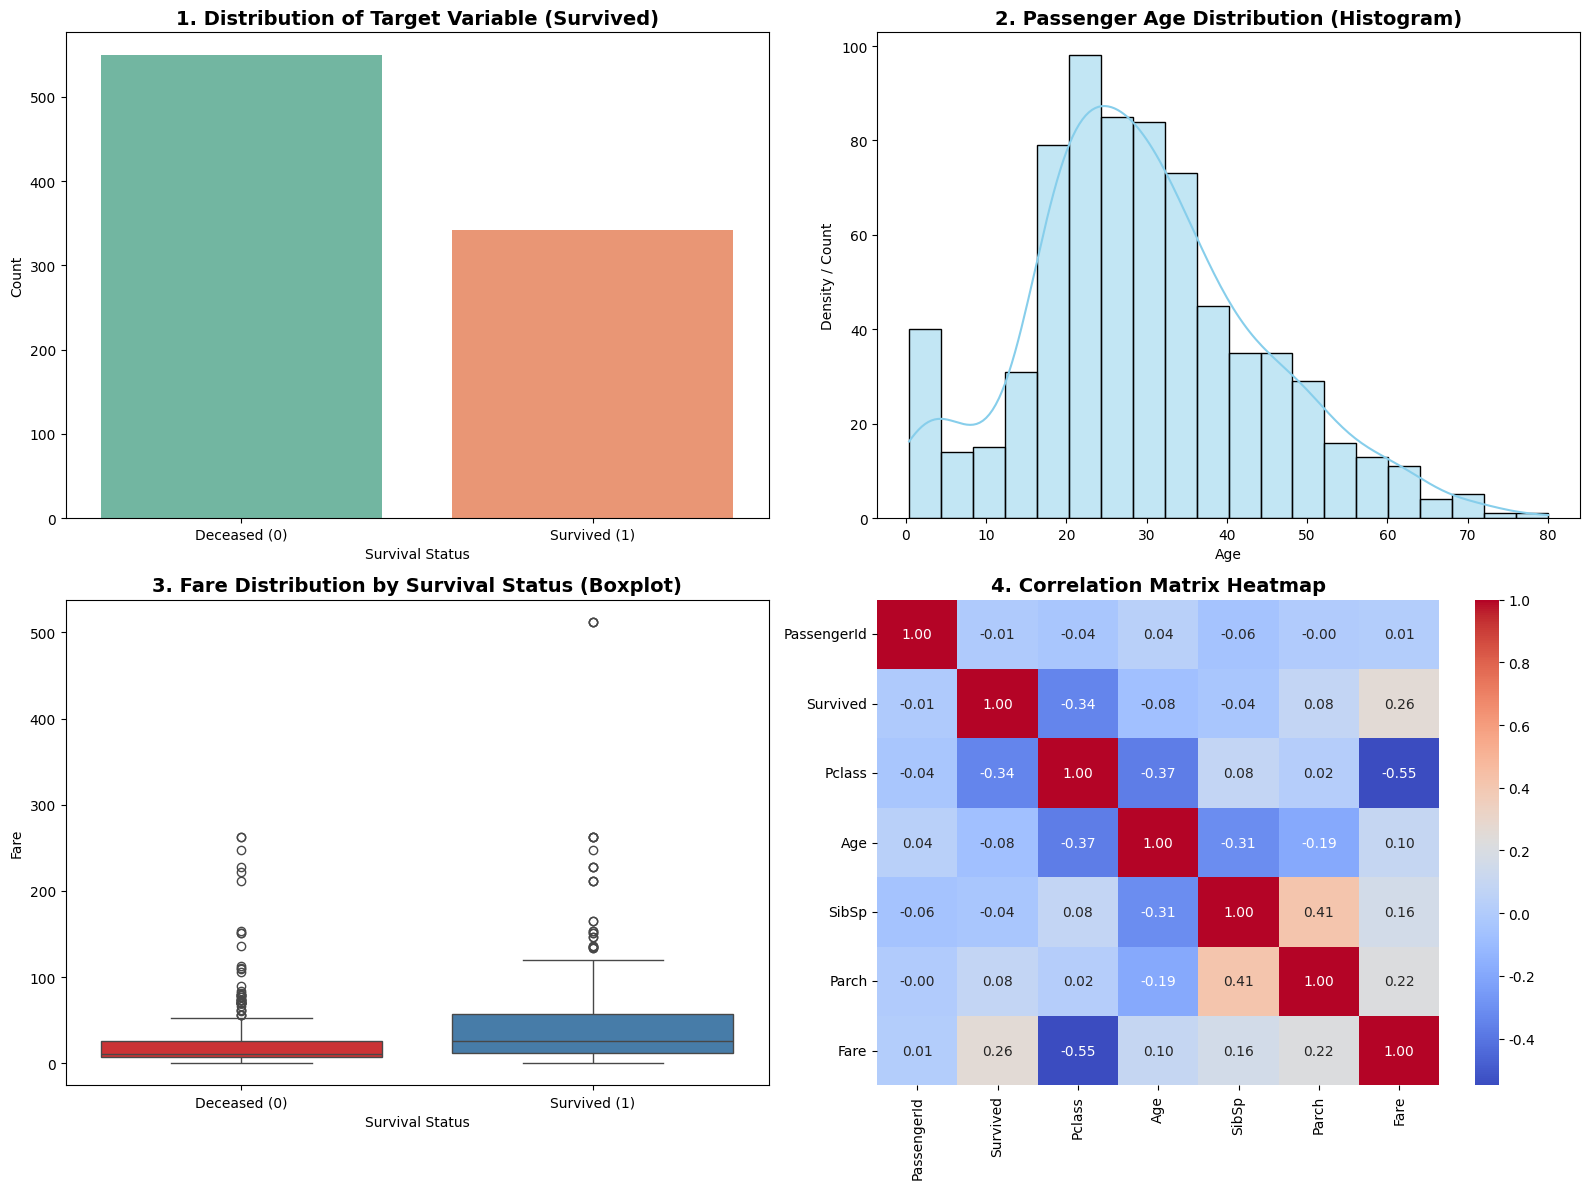

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정을 기본 영어 폰트(sans-serif)로 초기화
plt.rc('font', family='sans-serif')
plt.rcParams['axes.unicode_minus'] = False

# 그래프들을 한 번에 그리기 위한 격자 설정 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Countplot (타겟 변수 분포)
sns.countplot(x='Survived', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('1. Distribution of Target Variable (Survived)', fontsize=14, fontweight='bold')
axes[0, 0].set_xticklabels(['Deceased (0)', 'Survived (1)'])
axes[0, 0].set_xlabel('Survival Status')
axes[0, 0].set_ylabel('Count')

# 2. Histogram (나이 분포)
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('2. Passenger Age Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Density / Count')

# 3. Boxplot (요금 분포 및 이상치)
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('3. Fare Distribution by Survival Status (Boxplot)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(['Deceased (0)', 'Survived (1)'])
axes[1, 0].set_xlabel('Survival Status')
axes[1, 0].set_ylabel('Fare')

# 4. Heatmap (상관관계 분석)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('4. Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()